In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import time

from glob import glob

import plotly.express as px
import numpy as np
import seaborn as sns
from datetime import datetime
import pytz

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

! pip install xgboost
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

color_pal = sns.color_palette()
import requests
import joblib

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Assemble a list of path names that match a pattern in glob
ger_files = glob("Germany_ENTSO-E_*.csv")
ger_files

['Germany_ENTSO-E_2015.csv',
 'Germany_ENTSO-E_2016.csv',
 'Germany_ENTSO-E_2017.csv',
 'Germany_ENTSO-E_2018.csv',
 'Germany_ENTSO-E_2019.csv',
 'Germany_ENTSO-E_2020.csv',
 'Germany_ENTSO-E_2021.csv',
 'Germany_ENTSO-E_2022.csv',
 'Germany_ENTSO-E_2023.csv',
 'Germany_ENTSO-E_2024.csv',
 'Germany_ENTSO-E_2025.csv']

In [3]:
# Read all files into a list of DataFrames
germany_df_list = [pd.read_csv(file) for file in ger_files]

# Concatenate into one DataFrame
germany_entso_df = pd.concat(germany_df_list, ignore_index=True)

# Inspect a DataFrame using the info and shape 
germany_entso_df.info()
germany_entso_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366076 entries, 0 to 366075
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Timestamp  366076 non-null  object 
 1   Germany    366032 non-null  float64
dtypes: float64(1), object(1)
memory usage: 5.6+ MB


(366076, 2)

In [4]:
# Rename column
germany_entso_df.rename(columns={"Germany": "electricity_load_MW"}, inplace=True)

In [5]:
# Print only the top 5 row
germany_entso_df.head()

,Timestamp,electricity_load_MW
0,2015-01-01T00:00:00,45274.0
1,2015-01-01T00:15:00,44870.0
2,2015-01-01T00:30:00,44964.0
3,2015-01-01T00:45:00,44894.0
4,2015-01-01T01:00:00,44442.0


In [6]:
# Convert to naïve datetime
germany_entso_df["Timestamp"] = pd.to_datetime(germany_entso_df["Timestamp"])

# Localize to Europe/Berlin, handling DST gaps
germany_entso_df["Timestamp"] = germany_entso_df["Timestamp"].dt.tz_localize(
 'Europe/Berlin', nonexistent='shift_forward', ambiguous=True
)
# Set as index
germany_entso_df = germany_entso_df.set_index("Timestamp")
germany_entso_df

,electricity_load_MW
Timestamp,
2015-01-01 00:00:00+01:00,45274.0
2015-01-01 00:15:00+01:00,44870.0
2015-01-01 00:30:00+01:00,44964.0
2015-01-01 00:45:00+01:00,44894.0
2015-01-01 01:00:00+01:00,44442.0
...,...
2025-06-09 19:45:00+02:00,44272.0
2025-06-09 20:00:00+02:00,44751.0
2025-06-09 20:15:00+02:00,44367.0


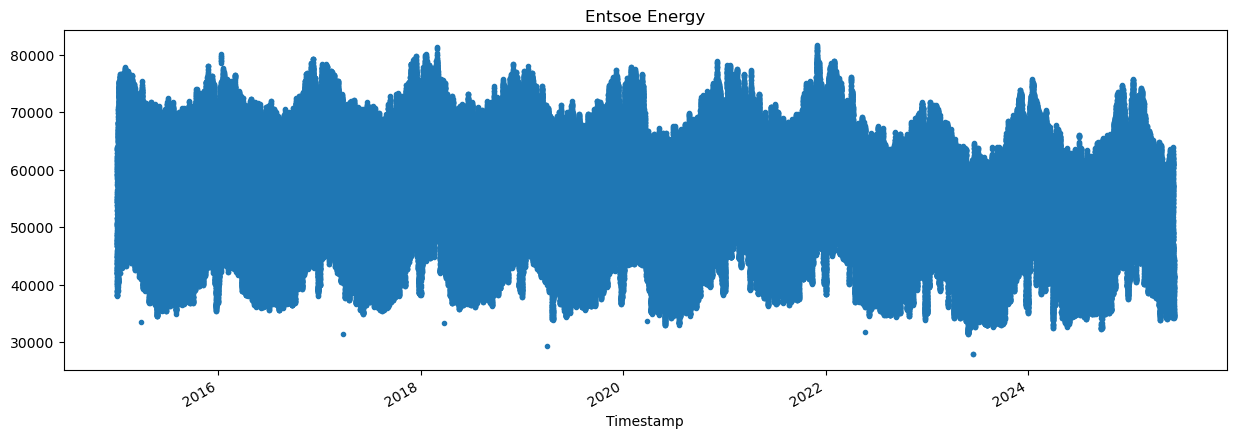

In [7]:
# Plot Electricity Load over Time before resmaple
germany_entso_df["electricity_load_MW"].plot(style=".", figsize=(15, 5), label = "color", title="Entsoe Energy");

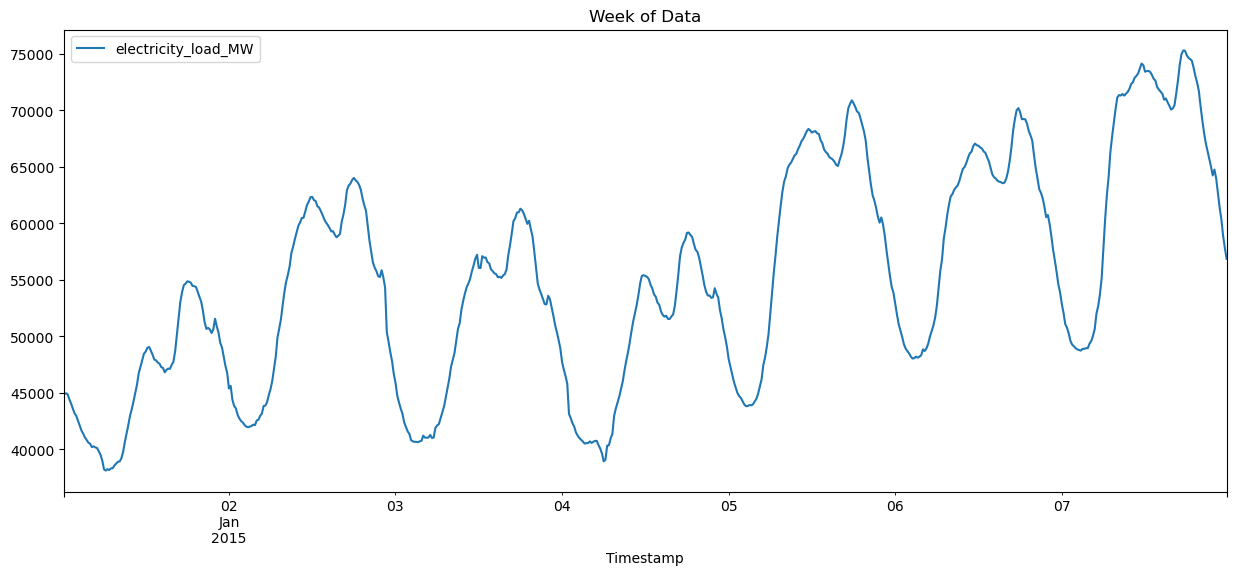

In [8]:
# Visualize Electricity Load (1 Week) over Time before resmaple
germany_entso_df["electricity_load_MW"].loc[(germany_entso_df.index > "2015-01-01") & (germany_entso_df.index < "2015-01-08")].plot(figsize=(15, 6), title="Week of Data")
plt.legend()
plt.show();

In [9]:
# Check the missing value
germany_entso_df.isnull().sum()

electricity_load_MW    44
dtype: int64

In [10]:
# Fill the missing value with Interpolation method
germany_entso_df["electricity_load_MW"] = germany_entso_df["electricity_load_MW"].interpolate(method="time")
germany_entso_df.head()

,electricity_load_MW
Timestamp,
2015-01-01 00:00:00+01:00,45274.0
2015-01-01 00:15:00+01:00,44870.0
2015-01-01 00:30:00+01:00,44964.0
2015-01-01 00:45:00+01:00,44894.0
2015-01-01 01:00:00+01:00,44442.0


In [11]:
# Resample
germany_entso_df = germany_entso_df["electricity_load_MW"].resample("1h").mean().to_frame()
germany_entso_df.head()

,electricity_load_MW
Timestamp,
2015-01-01 00:00:00+01:00,45000.50
2015-01-01 01:00:00+01:00,43833.25
2015-01-01 02:00:00+01:00,42322.25
2015-01-01 03:00:00+01:00,40966.00
2015-01-01 04:00:00+01:00,40283.50


In [12]:
# Check the missing value after Resample
germany_entso_df.isnull().sum()

electricity_load_MW    10
dtype: int64

In [13]:
# Fill the missing value after Resample with Interpolation method
germany_entso_df["electricity_load_MW"] = germany_entso_df["electricity_load_MW"].interpolate()
germany_entso_df.head()

,electricity_load_MW
Timestamp,
2015-01-01 00:00:00+01:00,45000.50
2015-01-01 01:00:00+01:00,43833.25
2015-01-01 02:00:00+01:00,42322.25
2015-01-01 03:00:00+01:00,40966.00
2015-01-01 04:00:00+01:00,40283.50


In [14]:
# Check the missing value
germany_entso_df.isnull().sum()

electricity_load_MW    0
dtype: int64

In [15]:
# Display the shape
germany_entso_df.shape

(91508, 1)

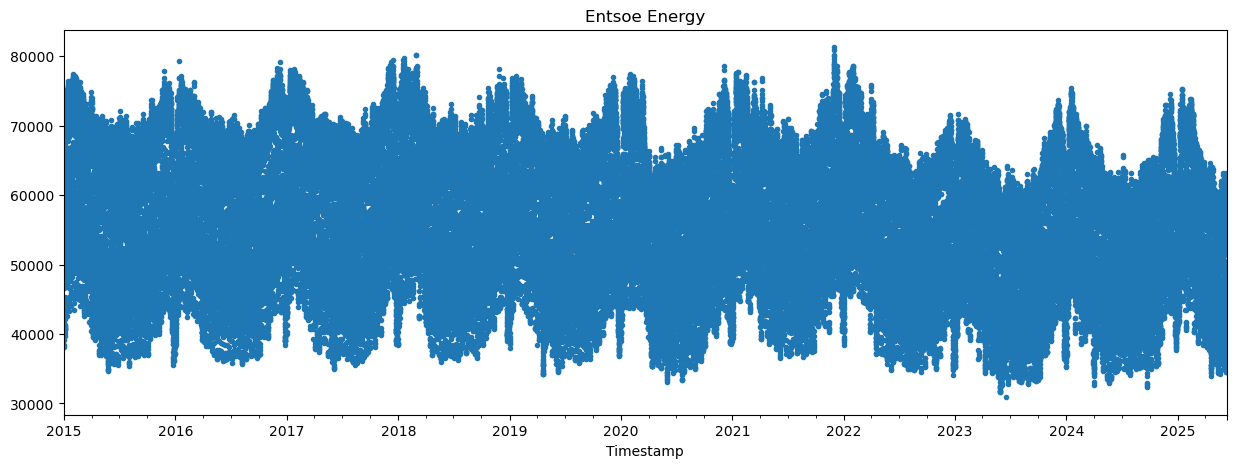

In [16]:
# Plot Electricity Load/Demand over Time after Resample
germany_entso_df["electricity_load_MW"].plot(style=".", figsize=(15, 5), label = "color", title="Entsoe Energy");
# No necssary to perform this analysis because plt.show()

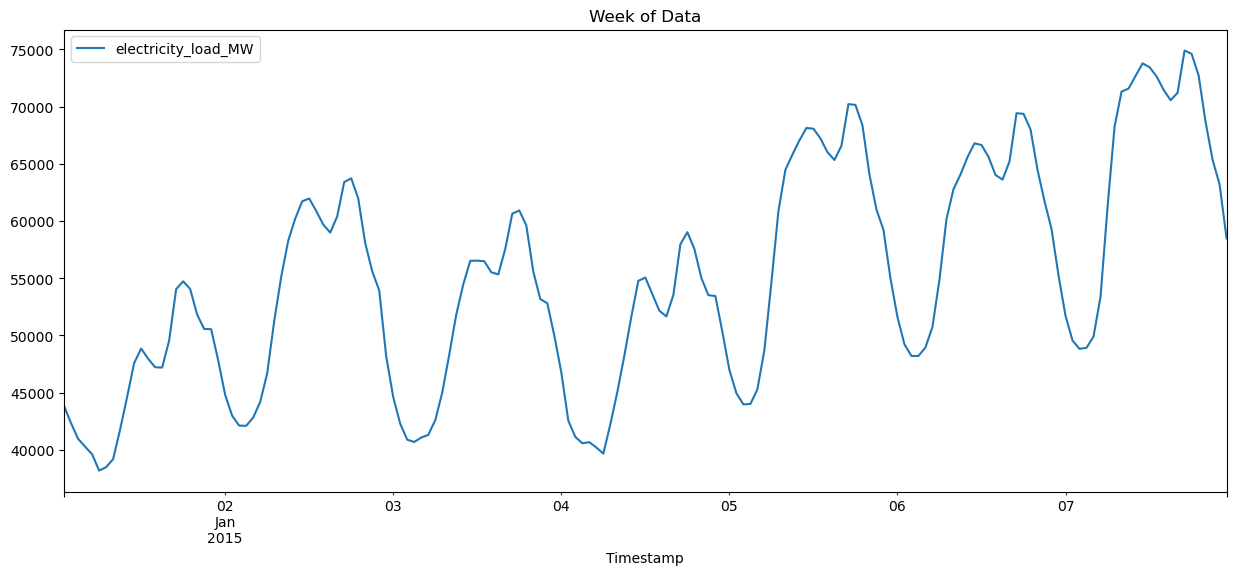

In [17]:
# Plot Electricity Load (in one week) over Time after Resample
germany_entso_df["electricity_load_MW"].loc[(germany_entso_df.index > "2015-01-01") & (germany_entso_df.index < "2015-01-08")].plot(figsize=(15, 6), title="Week of Data")
plt.legend()
plt.show();

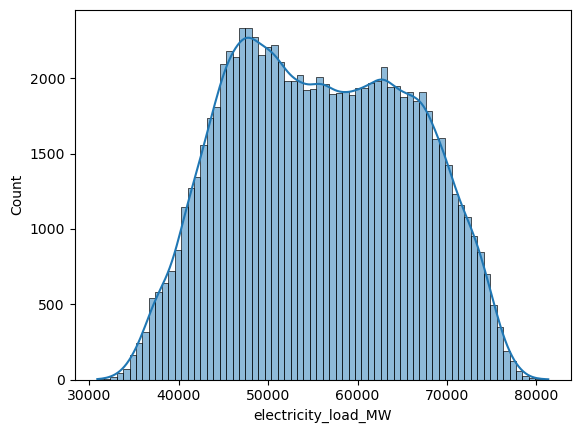

In [18]:
# Plot Histogram
sns.histplot(germany_entso_df["electricity_load_MW"], kde=True);

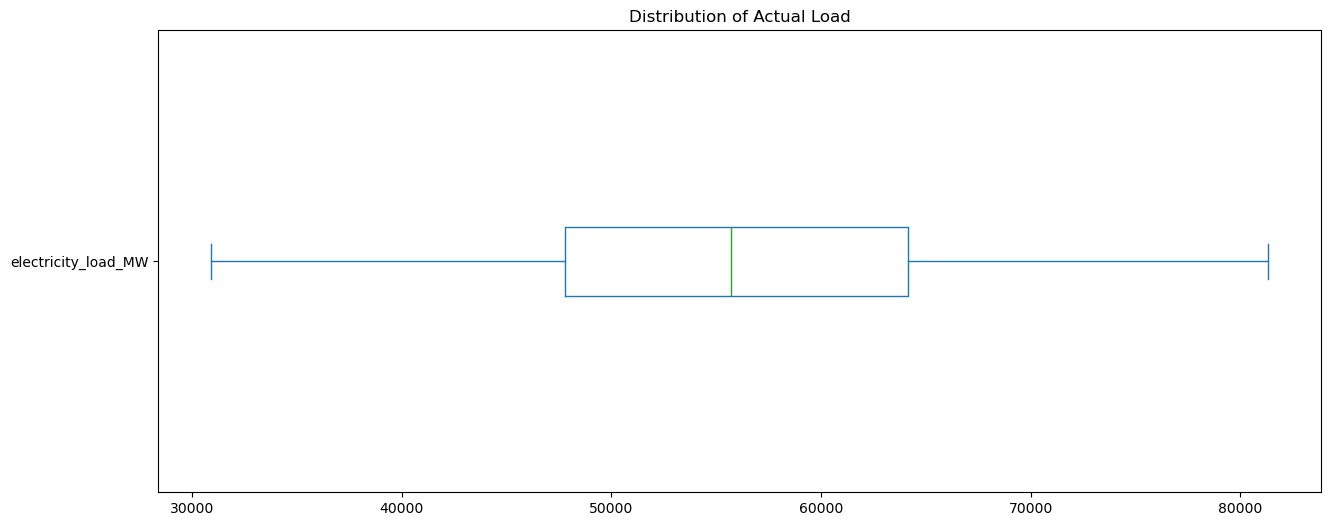

In [19]:
# Create a boxplot
fig, ax = plt.subplots(figsize=(15, 6))
germany_entso_df["electricity_load_MW"].plot(kind="box", vert=False, title="Distribution of Actual Load", ax=ax);

In [20]:
# Descriptive Statistics
germany_entso_df["electricity_load_MW"].describe().round(2)

count    91508.00
mean     55968.40
std       9971.47
min      30902.75
25%      47785.69
50%      55691.12
75%      64129.81
max      81319.50
Name: electricity_load_MW, dtype: float64